## Полносвязные нейронные сети (FCNN). Решение задачи классификации

In [1]:
import pandas as pd
import optuna
import joblib
import tensorflow as tf
import warnings
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score, f1_score
from sklearn.model_selection import cross_val_predict, train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.decomposition import PCA
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Чтение данных

In [2]:
data = pd.read_csv("../data/credit_card_fraud_filtered.csv")
data.head(10)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud,high_price_anomaly
0,57.877857,0.311140,1.945940,1,1,0,0,0,0
1,10.829943,0.175592,1.294219,1,0,0,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1,0,0
3,2.247564,5.600044,0.362663,1,1,0,1,0,0
4,44.190936,0.566486,2.222767,1,1,0,1,0,0
5,3.724019,0.956838,0.278465,1,0,0,1,0,0
6,4.848247,0.320735,1.273050,1,0,1,0,0,0
7,0.876632,2.503609,1.516999,0,0,0,0,0,0
8,8.839047,2.970512,2.361683,1,0,0,1,0,0
9,14.263530,0.158758,1.136102,1,1,0,1,0,0


### Выделение целевого признака и предиктора

In [3]:
y = data['fraud']
x = data.drop('fraud', axis=1)

### Оптимизация признакового пространства

In [4]:
pca = PCA(n_components=4)
x_pca = pd.DataFrame(pca.fit_transform(x, y), columns=pca.get_feature_names_out())

### MLPCLassifier

In [5]:
def print_mlp_architecture(pipeline):
    mlp = pipeline.named_steps['mlp']
    print(f"Входных признаков: {mlp.n_features_in_}")
    print(f"Скрытые слои: {mlp.hidden_layer_sizes}")
    print(f"Количество слоев (всего): {mlp.n_layers_}")
    print(f"Выходной слой: {mlp.n_outputs_}")
    print(f"Функция активации: {mlp.activation}")
    print(f"Оптимизатор: {mlp.solver}")

def plot_learning_curves(pipeline, title="Обучение модели"):
    mlp = pipeline.named_steps['mlp']
    
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(mlp.loss_curve_, label='Training Loss', color='blue', lw=2)
    ax1.set_xlabel('Эпохи')
    ax1.set_ylabel('Loss', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.6)

    if hasattr(mlp, 'validation_scores_'):
        ax2 = ax1.twinx()
        ax2.plot(mlp.validation_scores_, label='Validation Accuracy', color='red', linewidth=2)
        ax2.set_ylabel('Accuracy', color='red') 
        ax2.tick_params(axis='y', labelcolor='red')
        ax2.set_ylim(0, 1)
    
    plt.title(title)
    fig.tight_layout()
    plt.show()

f1 = 0.9329


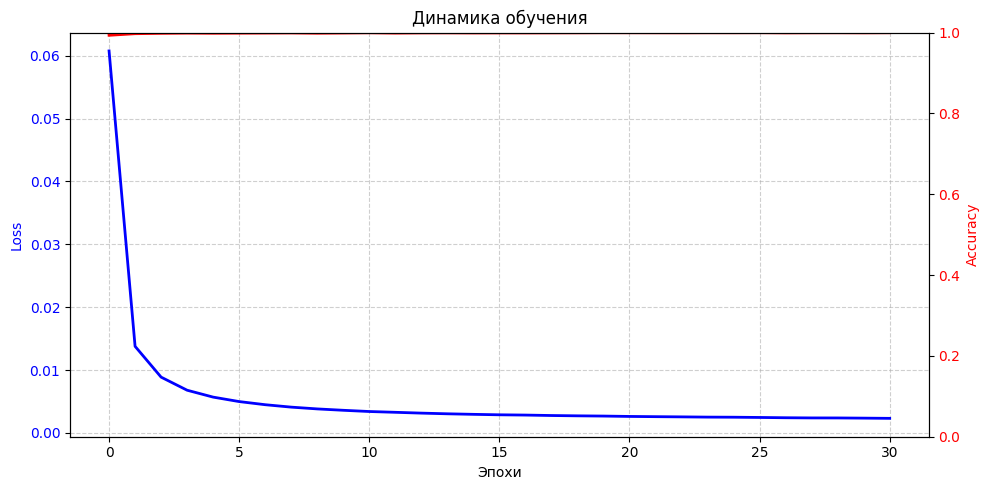

In [6]:
base_pipeline = ImbPipeline([  
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=81, sampling_strategy='auto')), 
    ('mlp', MLPClassifier(early_stopping=True, max_iter=1000, random_state=81))
])

base_kf = KFold(n_splits=5, shuffle=True, random_state=81)

y_pred_base = cross_val_predict(base_pipeline, x_pca, y, cv=base_kf, n_jobs=-1)
f1_base = f1_score(y, y_pred_base)
print(f"f1 = {round(f1_base, 4)}")

base_pipeline.fit(x_pca, y)

plot_learning_curves(base_pipeline, title="Динамика обучения")

In [7]:
print_mlp_architecture(pipeline=base_pipeline)

Входных признаков: 4
Скрытые слои: (100,)
Количество слоев (всего): 3
Выходной слой: 1
Функция активации: relu
Оптимизатор: adam


In [8]:
joblib.dump(base_pipeline, '../models/base_mlp_classification.pkl')

['../models/base_mlp_classification.pkl']

### MLPClassifier с Optuna

In [9]:
def objective(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical(
            'hidden_layer_sizes', 
            [(50,), (100,), (100, 50), (150, 100)] 
        ),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha': trial.suggest_float('alpha', 1e-4, 1e-2, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-3, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [128, 256, 'auto']), 
    }
    
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smoteenn', SMOTEENN(random_state=81, sampling_strategy='auto')), 
        ('mlp', MLPClassifier(
            **params,
            solver='adam', 
            random_state=81,
            early_stopping=True,
            max_iter=400,          
            n_iter_no_change=10,   
            validation_fraction=0.1
        ))
    ])

    cv = KFold(n_splits=3, shuffle=True, random_state=81) 
    
    scores = cross_val_score(
        pipeline, 
        x_pca, 
        y, 
        cv=cv, 
        scoring='f1',
        n_jobs=-1 
    )
    
    return scores.mean()

In [10]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)

[I 2026-05-07 20:15:59,365] A new study created in memory with name: no-name-bdb4f39f-d115-4841-925a-d2b8a5a54650


  0%|          | 0/10 [00:00<?, ?it/s]

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  optuna_warn(message)
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  optuna_warn(message)
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  optuna_warn(message)
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/p

[I 2026-05-07 20:16:37,992] Trial 0 finished with value: 0.9297912500664515 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'tanh', 'alpha': 0.0009463795859733268, 'learning_rate_init': 0.007944912731347013, 'batch_size': 128}. Best is trial 0 with value: 0.9297912500664515.
[I 2026-05-07 20:18:36,903] Trial 1 finished with value: 0.9337883924616315 and parameters: {'hidden_layer_sizes': (150, 100), 'activation': 'tanh', 'alpha': 0.0033011815618502697, 'learning_rate_init': 0.0014143654707215755, 'batch_size': 'auto'}. Best is trial 1 with value: 0.9337883924616315.
[I 2026-05-07 20:19:06,625] Trial 2 finished with value: 0.9306460569730551 and parameters: {'hidden_layer_sizes': (50,), 'activation': 'tanh', 'alpha': 0.0006391427907553357, 'learning_rate_init': 0.001812879216330721, 'batch_size': 256}. Best is trial 1 with value: 0.9337883924616315.
[I 2026-05-07 20:20:31,137] Trial 3 finished with value: 0.9388953644163814 and parameters: {'hidden_layer_sizes': (100, 50), 

In [11]:
joblib.dump(study, '../models/study_mlp_optuna.pkl')

['../models/study_mlp_optuna.pkl']

R^2 = 0.853


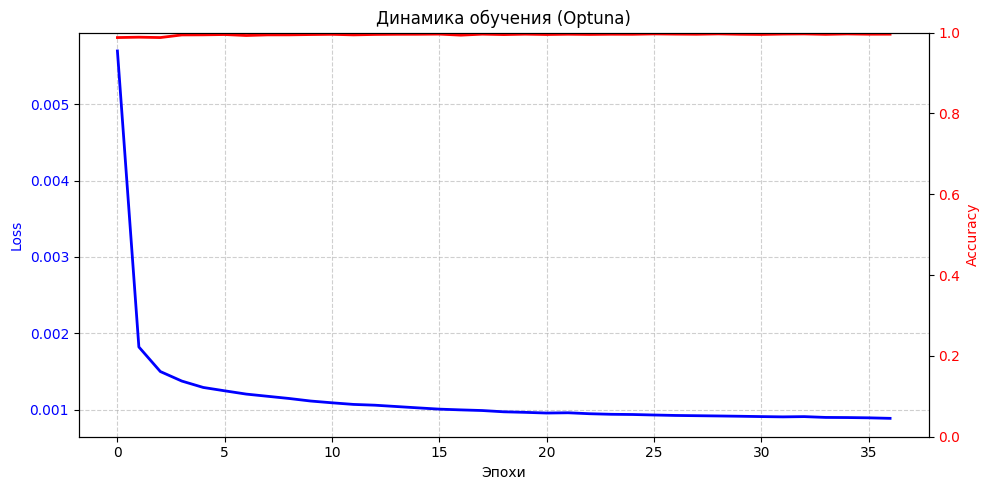

Входных признаков: 4
Скрытые слои: (150, 100)
Количество слоев (всего): 4
Выходной слой: 1
Функция активации: tanh
Оптимизатор: adam


In [12]:
optuna_tf_params = study.best_params
optuna_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=81, sampling_strategy='auto')),
    ('mlp', MLPRegressor(
        **optuna_tf_params,
        random_state=81,
        early_stopping=True,
        max_iter=400,
        n_iter_no_change=10,
        validation_fraction=0.1
    ))
])

base_kf = KFold(n_splits=5, shuffle=True, random_state=81)

y_pred_optuna = cross_val_predict(optuna_pipeline, x_pca, y, cv=base_kf, n_jobs=-1)
f1_optuna = r2_score(y, y_pred_optuna)
print(f"R^2 = {round(f1_optuna, 4)}")

optuna_pipeline.fit(x_pca, y)
plot_learning_curves(optuna_pipeline, title="Динамика обучения (Optuna)")
print_mlp_architecture(optuna_pipeline)

fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig2 = optuna.visualization.plot_optimization_history(study)
fig2.show()

In [43]:
joblib.dump(optuna_pipeline, 'mlp_classification_optuna.pkl')

['mlp_classification_optuna.pkl']

In [44]:
results = []

results.append({"Algorithm" : "MLPClassifier Base", "f1": round(f1_base, 4)})
results.append({"Algorithm" : "MLPClassifier Optuna", "f1": round(f1_optuna, 4)})

In [45]:
res = pd.DataFrame(results)
res

,Algorithm,f1
0,MLPClassifier Base,0.9329
1,MLPClassifier Optuna,0.8530


### TensorFlow

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.15)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

sme = SMOTEENN(random_state=81)
x_train, y_train = sme.fit_resample(x_train, y_train)

In [17]:
def f1_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.round(y_pred), tf.float32) # Порог 0.5
    
    tp = tf.reduce_sum(y_true * y_pred)
    predicted_positives = tf.reduce_sum(y_pred)
    possible_positives = tf.reduce_sum(y_true)
    
    precision = tp / (predicted_positives + tf.keras.backend.epsilon())
    recall = tp / (possible_positives + tf.keras.backend.epsilon())
    
    return 2 * ((precision * recall) / (precision + recall + tf.keras.backend.epsilon()))

def plot_history(history, title):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(history.history['loss'], color='blue', label='Loss')
    ax1.plot(history.history['val_loss'], '--', color='blue', alpha=0.6, label='Loss')
    ax1.set_xlabel('Эпохи')
    ax1.set_ylabel('Loss', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2 = ax1.twinx()
    ax2.plot(history.history['f1_metric'], color='red', label='F1 Score')
    ax2.plot(history.history['val_f1_metric'], '--', color='red', alpha=0.6, label='F1')
    ax2.set_ylabel('F1 Score', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title(title)
    fig.legend()
    fig.tight_layout()
    plt.show()

In [18]:
base_tensorflow = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.05),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)

In [ ]:
base_tensorflow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='binary_crossentropy', 
    metrics=[f1_metric]
)

history = base_tensorflow.fit(x_train, y_train, epochs=50)
y_pred_base_tf = base_tensorflow.predict(x_test)

y_pred_prob = base_tensorflow.predict(x_test)
y_pred_base_tf = (y_pred_prob > 0.5).astype(int)

Epoch 1/50
43699/43699 [==============================] - 17s 387us/step - loss: 0.0201 - f1_metric: 0.9937
Epoch 2/50
43699/43699 [==============================] - 16s 361us/step - loss: 0.0121 - f1_metric: 0.9965
Epoch 3/50
43699/43699 [==============================] - 16s 361us/step - loss: 0.0122 - f1_metric: 0.9967
Epoch 4/50
43699/43699 [==============================] - 16s 361us/step - loss: 0.0219 - f1_metric: 0.9942
Epoch 5/50
43699/43699 [==============================] - 16s 361us/step - loss: 0.0189 - f1_metric: 0.9936
Epoch 6/50
43699/43699 [==============================] - 16s 361us/step - loss: 0.0138 - f1_metric: 0.9965
Epoch 7/50
43699/43699 [==============================] - 16s 362us/step - loss: 0.0124 - f1_metric: 0.9962
Epoch 8/50
43699/43699 [==============================] - 16s 361us/step - loss: 0.0144 - f1_metric: 0.9956
Epoch 9/50
43699/43699 [==============================] - 16s 362us/step - loss: 0.0118 - f1_metric: 0.9972
Epoch 10/50
43699/43699 [===

In [21]:
f1_base_tf = f1_score(y_test, y_pred_base_tf)
print(f"f1 = {f1_base_tf}")

f1 = 0.7522871217452498


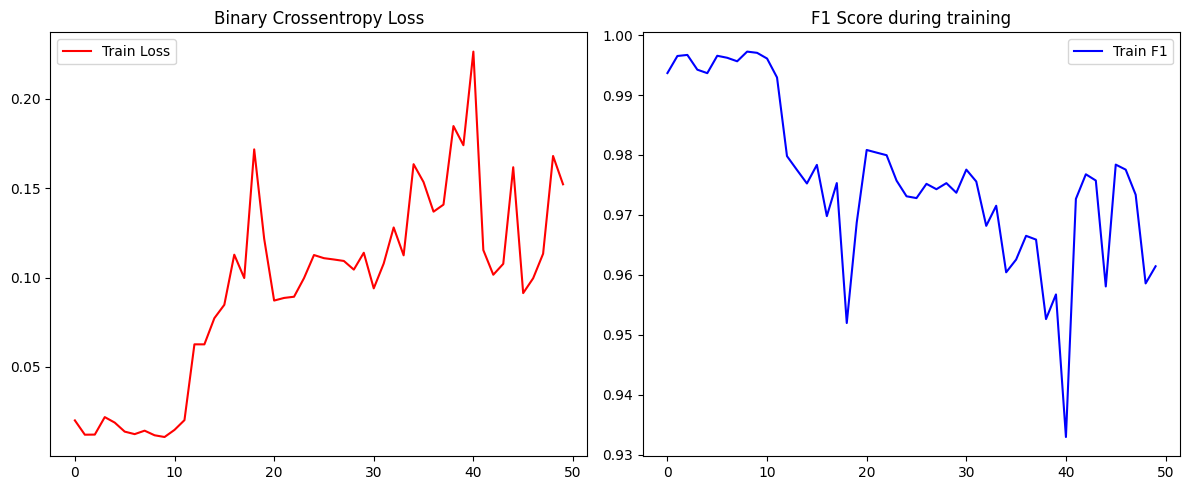

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 128)               8320      
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 32)                2080      
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dense_5 (Dense)             (None, 1)                 1

In [ ]:
# plot_history(history=history, title='Динамика обучения (Base TensorFlow)')
plt.figure(figsize=(12, 5))

# График Loss (красным)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='red')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], '--', label='Val Loss', color='red', alpha=0.6)
plt.title('Binary Crossentropy Loss')
plt.legend()

# График F1
plt.subplot(1, 2, 2)
plt.plot(history.history['f1_metric'], label='Train F1', color='blue')
if 'val_f1_metric' in history.history:
    plt.plot(history.history['val_f1_metric'], '--', label='Val F1', color='blue', alpha=0.6)
plt.title('F1 Score during training')
plt.legend()

plt.tight_layout()
plt.show()
base_tensorflow.summary()

In [ ]:
plt.figure(figsize=(12, 5))

# График Loss (красным)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='red')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], '--', label='Val Loss', color='red', alpha=0.6)
plt.title('Binary Crossentropy Loss')
plt.legend()

# График F1
plt.subplot(1, 2, 2)
plt.plot(history.history['f1_metric'], label='Train F1', color='blue')
if 'val_f1_metric' in history.history:
    plt.plot(history.history['val_f1_metric'], '--', label='Val F1', color='blue', alpha=0.6)
plt.title('F1 Score during training')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
base_tensorflow.save('../models/base_tf_classification.keras')

In [46]:
results.append({"Algorithm" : "TensorFlow Base", "f1": round(f1_base_tf, 4)})

res = pd.DataFrame(results)
res

,Algorithm,f1
0,MLPClassifier Base,0.9329
1,MLPClassifier Optuna,0.8530
2,TensorFlow Base,0.7523


### TensorFlow с Optuna

In [26]:
from tensorflow import keras
    

In [27]:
input_shape = x_train.shape[1]
num_classes = len(np.unique(np.concatenate([y_train, y_test])))

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 0.1, log=True)
    batch_size = trial.suggest_int('batch_size', 16, 128, step=32)

    if optimizer_name == 'adam':
        optimizer = keras.optimizers.legacy.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = keras.optimizers.legacy.SGD(learning_rate=learning_rate)
    else:  
        optimizer = keras.optimizers.legacy.RMSprop(learning_rate=learning_rate)
    
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_shape,)))
    
    for i in range(n_layers):
        n_units = trial.suggest_int(f'n_units_l{i}', 16, 256, step=32)
        model.add(keras.layers.Dense(n_units, activation=activation))
        dropout = trial.suggest_float(f'dropout_l{i}', 0.0, 0.5)
        model.add(keras.layers.Dropout(dropout))
    
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=[f1_metric])
    
    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=20,
        verbose=0
    )
    f1 = max(history.history['f1_metric'])

    return float(f1)

In [29]:
study_tf = optuna.create_study(direction='maximize')
study_tf.optimize(objective, n_trials=2, show_progress_bar=True)

optuna_tf_params = study_tf.best_params
print(f"f1 = {round(study_tf.best_value, 4)}")


[I 2026-05-07 21:26:05,049] A new study created in memory with name: no-name-2fada55b-9145-4e7e-9f4e-c334b37865d1


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2026-05-07 21:31:48,651] Trial 0 finished with value: 0.9691399335861206 and parameters: {'n_layers': 1, 'activation': 'tanh', 'optimizer': 'rmsprop', 'learning_rate': 0.00018070392999669917, 'batch_size': 16, 'n_units_l0': 16, 'dropout_l0': 0.2721095564333489}. Best is trial 0 with value: 0.9691399335861206.
[I 2026-05-07 21:34:17,061] Trial 1 finished with value: 0.9981421828269958 and parameters: {'n_layers': 2, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.006248193105159974, 'batch_size': 80, 'n_units_l0': 112, 'dropout_l0': 0.4688935514969466, 'n_units_l1': 240, 'dropout_l1': 0.1654652280511652}. Best is trial 1 with value: 0.9981421828269958.
f1 = 0.9981


In [30]:
optuna_tf = keras.Sequential()
optuna_tf.add(keras.layers.Input(shape=(input_shape,)))

for i in range(optuna_tf_params['n_layers']):
    n_units = optuna_tf_params[f'n_units_l{i}']
    optuna_tf.add(keras.layers.Dense(n_units, activation=optuna_tf_params['activation']))
    optuna_tf.add(keras.layers.Dropout(optuna_tf_params[f'dropout_l{i}']))

optuna_tf.add(keras.layers.Dense(1, activation='sigmoid'))

optimizer_name = optuna_tf_params['optimizer']
lr = optuna_tf_params['learning_rate']
if optimizer_name == 'adam':
    optimizer = keras.optimizers.legacy.Adam(learning_rate=lr)
elif optimizer_name == 'sgd':
    optimizer = keras.optimizers.legacy.SGD(learning_rate=lr)
else:
    optimizer = keras.optimizers.legacy.RMSprop(learning_rate=lr)

optuna_tf.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[f1_metric])

In [31]:
optuna_tf.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 112)               560       
                                                                 
 dropout_11 (Dropout)        (None, 112)               0         
                                                                 
 dense_22 (Dense)            (None, 240)               27120     
                                                                 
 dropout_12 (Dropout)        (None, 240)               0         
                                                                 
 dense_23 (Dense)            (None, 1)                 241       
                                                                 
Total params: 27921 (109.07 KB)
Trainable params: 27921 (109.07 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [32]:
optuna_tf.save('../models/optuna_tf_classification.keras')

In [40]:
history_optuna_tf = optuna_tf.fit(
    x_train, y_train,
    batch_size=optuna_tf_params['batch_size'],
    epochs=10
)

y_pred_prob = optuna_tf.predict(x_test)
y_pred_optuna = (y_pred_prob > 0.5).astype(int)
f1_optuna_tf = f1_score(y_test, y_pred_optuna)
print(f"f1 = {f1_optuna_tf}")

Epoch 1/10
17480/17480 [==============================] - 9s 514us/step - loss: 0.0085 - f1_metric: 0.9977
Epoch 2/10
17480/17480 [==============================] - 9s 536us/step - loss: 0.0085 - f1_metric: 0.9976
Epoch 3/10
17480/17480 [==============================] - 9s 487us/step - loss: 0.0081 - f1_metric: 0.9978
Epoch 4/10
17480/17480 [==============================] - 8s 476us/step - loss: 0.0078 - f1_metric: 0.9979
Epoch 5/10
17480/17480 [==============================] - 8s 475us/step - loss: 0.0081 - f1_metric: 0.9979
Epoch 6/10
17480/17480 [==============================] - 8s 483us/step - loss: 0.0073 - f1_metric: 0.9980
Epoch 7/10
17480/17480 [==============================] - 9s 506us/step - loss: 0.0077 - f1_metric: 0.9980
Epoch 8/10
17480/17480 [==============================] - 8s 484us/step - loss: 0.0072 - f1_metric: 0.9980
Epoch 9/10
17480/17480 [==============================] - 8s 483us/step - loss: 0.0072 - f1_metric: 0.9981
Epoch 10/10
4148/4148 [==============

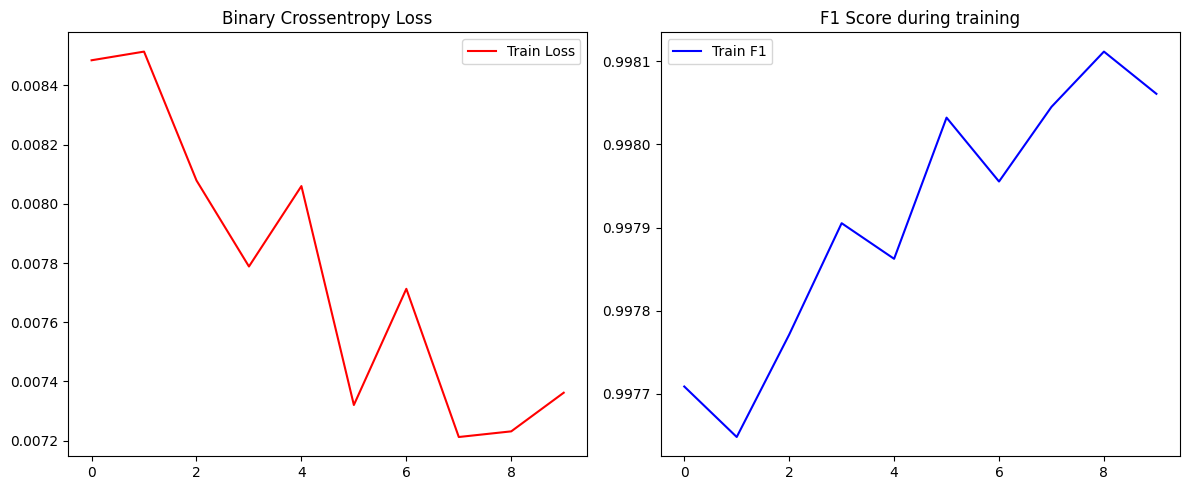

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 112)               560       
                                                                 
 dropout_11 (Dropout)        (None, 112)               0         
                                                                 
 dense_22 (Dense)            (None, 240)               27120     
                                                                 
 dropout_12 (Dropout)        (None, 240)               0         
                                                                 
 dense_23 (Dense)            (None, 1)                 241       
                                                                 
Total params: 27921 (109.07 KB)
Trainable params: 27921 (109.07 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [42]:
plt.figure(figsize=(12, 5))

# График Loss (красным)
plt.subplot(1, 2, 1)
plt.plot(history_optuna_tf.history['loss'], label='Train Loss', color='red')
if 'val_loss' in history_optuna_tf.history:
    plt.plot(history_optuna_tf.history['val_loss'], '--', label='Val Loss', color='red', alpha=0.6)
plt.title('Binary Crossentropy Loss')
plt.legend()

# График F1
plt.subplot(1, 2, 2)
plt.plot(history_optuna_tf.history['f1_metric'], label='Train F1', color='blue')
if 'val_f1_metric' in history_optuna_tf.history:
    plt.plot(history_optuna_tf.history['val_f1_metric'], '--', label='Val F1', color='blue', alpha=0.6)
plt.title('F1 Score during training')
plt.legend()

plt.tight_layout()
plt.show()

optuna_tf.summary()

fig = optuna.visualization.plot_param_importances(study_tf)
fig.show()

fig2 = optuna.visualization.plot_optimization_history(study_tf)
fig2.show()

In [47]:
results.append({"Algorithm" : "TensorFlow Optuna", "f1": round(f1_optuna_tf, 4)})

res = pd.DataFrame(results)
res

,Algorithm,f1
0,MLPClassifier Base,0.9329
1,MLPClassifier Optuna,0.8530
2,TensorFlow Base,0.7523
3,TensorFlow Optuna,0.9307
